In [15]:
import warnings
warnings.filterwarnings("ignore")
import json
import sys
import os
import pickle
import time
import numpy as np
from pathlib import Path
from datetime import datetime

sys.path.insert(0, os.getcwd())

os.chdir("E:\\TaiLieuBachKhoa\\DATN\\LLMCaching-Access-Log-Analysis")
from src.ingestion.schema import NormalizedLog
from src.detection.rule_based.detector import RuleDetector
from src.detection.ml.detector import MLDetector
from src.detection.temporal_buffer import TemporalBuffer
from src.detection.merger import merge, should_flag
from src.llm.cache import SemanticCache

In [16]:
def precision(tp, fp):
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0

def recall(tp, fn):
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def f1_score(p, r):
    return 2 * p * r / (p + r) if (p + r) > 0 else 0.0

def entry_to_log(e):
    return NormalizedLog(
        timestamp=datetime.now(),
        source_ip=e.get("ip", "0.0.0.0"),
        method=e.get("method", "GET"),
        path=e.get("path", "/"),
        status_code=e.get("status", 200),
        source="synthetic",
        query_string=e.get("query", "") or None,
        user_agent=e.get("user_agent", ""),
    )

print("Loading test datasets...")
test_path = Path("E:\\TaiLieuBachKhoa\\DATN\\LLMCaching-Access-Log-Analysis\\data\\synthetic\\test.jsonl")
entries = [json.loads(l) for l in test_path.read_text(encoding="utf-8").splitlines() if l.strip()]

# Initialize LLM for Stage 2
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass
    
# llm_provider = os.environ.get("LLM_PROVIDER", "ollama").lower()
# gemini_model = None
# ollama_model_name = os.environ.get("OLLAMA_MODEL", "gemma4:e4b")

# if llm_provider == "gemini":
#     try:
#         import google.generativeai as genai
#         api_key = os.environ.get("GEMINI_API_KEY")
#         if api_key:
#             genai.configure(api_key=api_key)
#             gemini_model = genai.GenerativeModel("gemini-1.5-flash")
#             print("Gemini initialized for Stage 2 verification.")
#         else:
#             print("Warning: GEMINI_API_KEY not found. Fallback to Stage 1.")
#     except ImportError:
#         print("Warning: google-generativeai not installed. Fallback to Stage 1.")
# elif llm_provider == "ollama":
#     print(f"Ollama initialized for Stage 2 verification using model: {ollama_model_name}")

# llm_cache = {}

# try:
#     semantic_cache = SemanticCache()
#     print("Semantic Cache initialized.")
# except Exception as e:
#     semantic_cache = None
#     print(f"Semantic Cache unavailable: {e}")

rules = RuleDetector()
ml = MLDetector()
buffer = TemporalBuffer()

# Load content model components for content-only baseline
with open("data/models/lgbm_content.pkl", "rb") as f:
    c = pickle.load(f)
content_model = c["model"]
vectorizer = c["vectorizer"]

# Load IF model
with open("data/models/isolation_forest.pkl", "rb") as f:
    if_model = pickle.load(f)

# Counters for 5 configurations
# 1. Isolation Forest
if_tp, if_fp, if_fn, if_tn = 0, 0, 0, 0
# 2. Rule only
r_tp, r_fp, r_fn, r_tn = 0, 0, 0, 0
# 3. Content ML only
c_tp, c_fp, c_fn, c_tn = 0, 0, 0, 0
# 4. Stage 1
s1_tp, s1_fp, s1_fn, s1_tn = 0, 0, 0, 0
# 5. Stage 2
s2_tp, s2_fp, s2_fn, s2_tn = 0, 0, 0, 0

total_attacks = 0

out_f = open("data/llm_predictions.txt", "w", encoding="utf-8")
out_f.write("stt | is_s2_attack | label\n")

print("Evaluating models over entries...")
lines = 1
total_lines = len(entries)  
for e in entries:
    if lines % 10 == 0:
        print(f"Processing line {lines}/{total_lines}")
    lines += 1
    label = 1 if e.get("label", 0) > 0 else 0
    if label == 1:
        total_attacks += 1
        
    log = entry_to_log(e)
    
    # 1. Isolation Forest
    text = f"{log.path or ''} {log.query_string or ''} {log.user_agent[:100]}"
    if_pred = -1 if if_model.predict([text])[0] == -1 else 0  # IF returns -1 for anomaly, 1 for normal
    is_if_attack = if_pred == -1
    if is_if_attack and label == 1: if_tp += 1
    elif is_if_attack and label == 0: if_fp += 1
    elif not is_if_attack and label == 1: if_fn += 1
    else: if_tn += 1
        
    # 2. Rule only
    r = rules.detect(log)
    is_rule_attack = r.max_score >= 0.5
    if is_rule_attack and label == 1: r_tp += 1
    elif is_rule_attack and label == 0: r_fp += 1
    elif not is_rule_attack and label == 1: r_fn += 1
    else: r_tn += 1
        
    # 3. Content ML only
    X = vectorizer.transform([f"{log.path or ''} {log.query_string or ''} {log.user_agent[:100]}"])
    probs = content_model.predict_proba(X)[0]
    content_score = float(1.0 - probs[0])
    is_content_attack = content_score >= 0.5
    if is_content_attack and label == 1: c_tp += 1
    elif is_content_attack and label == 0: c_fp += 1
    elif not is_content_attack and label == 1: c_fn += 1
    else: c_tn += 1
        
    # 4. Stage 1
    log.rule_score = r.max_score
    window = buffer.add(log)
    cs, bs = ml.score(log, window, r.max_score)
    merged = merge(r.max_score, cs, bs, buffer.multiplier(log.source_ip))
    is_s1_attack = should_flag(merged)
    
    if is_s1_attack and label == 1: s1_tp += 1
    elif is_s1_attack and label == 0: s1_fp += 1
    elif not is_s1_attack and label == 1: s1_fn += 1
    else: s1_tn += 1

    # 5. Stage 2 (Fast LLM Verification)
#     is_s2_attack = False
#     if is_s1_attack:
#         cache_key = f"{log.method}|{log.path}|{log.query_string}|{log.user_agent}"
#         if cache_key in llm_cache:
#             is_s2_attack = llm_cache[cache_key]
#         else:
#             emb = None
#             cached_analysis = None
#             if semantic_cache:
#                 try:
#                     cached_analysis, emb = semantic_cache.lookup(log)
#                 except Exception as e:
#                     pass
            
#             if cached_analysis is not None:
#                 is_s2_attack = cached_analysis.get("is_attack", True)
#                 llm_cache[cache_key] = is_s2_attack
#             else:
#                 request_text = f"{log.method} {log.path} {log.query_string} {log.user_agent}"
#                 if len(request_text) > 1000:
#                     request_text = request_text[:1000] + "...[TRUNC]"
#                 prompt = f"Is this web request an attack? Reply ONLY '1' for attack or '0' for normal.\nRequest: {request_text}"
                
#                 if llm_provider == "gemini" and gemini_model:
#                     try:
#                         # Add slight delay to avoid rate limit if using Gemini free tier
#                         time.sleep(0.5) 
#                         resp = gemini_model.generate_content(prompt)
#                         resp_text = resp.text.strip()
#                         if resp_text:
#                             is_s2_attack = "1" in resp_text
#                         else:
#                             is_s2_attack = True
#                     except Exception as e:
#                         # If API fails (e.g. rate limit), fallback to Stage 1 decision
#                         is_s2_attack = True 
#                 elif llm_provider == "ollama":
#                     try:
#                         import requests
#                         payload = {
#                             "model": ollama_model_name,
#                             "prompt": prompt,
#                             "stream": False,
#                             "options": {
#                                 "temperature": 0.0,
#                                 "num_gpu": 40
#                             }
#                         }
#                         resp = requests.post("http://localhost:11434/api/generate", json=payload, timeout=200)
#                         if resp.status_code == 200:
#                             resp_text = resp.json().get("response", "").strip()
#                             if resp_text:
#                                 is_s2_attack = "1" in resp_text
#                             else:
#                                 is_s2_attack = True
#                         else:
#                             print(f"[Warn] Ollama returned status {resp.status_code}")
#                             is_s2_attack = True
#                         if lines <= 20:
#                             print(f"[Debug] Line {lines}")
#                             print(f"Request: {log.method} {log.path} {log.query_string} {log.user_agent}")
#                             print(f"LLM response: {resp.json().get('response', '')}")
#                             print(f"Is attack: {is_s2_attack}")
#                             print(f"Label: {label}")
#                     except Exception as e:
#                         print(f"[Error] Ollama request failed: {e}")
#                         is_s2_attack = True
#                 else:
#                     # Fallback to Stage 1 if no LLM configured
#                     is_s2_attack = True
                    
#                 llm_cache[cache_key] = is_s2_attack
#                 if semantic_cache and emb is not None:
#                     semantic_cache.store(emb, {"is_attack": is_s2_attack})
            
#         if is_s2_attack and label == 1: s2_tp += 1
#         elif is_s2_attack and label == 0: s2_fp += 1
#         elif not is_s2_attack and label == 1: s2_fn += 1
#         else: s2_tn += 1
#     else:
#         if label == 1: s2_fn += 1
#         else: s2_tn += 1
        
#     out_f.write(f"stt {lines - 1}: {1 if is_s2_attack else 0} | label={label}\n")
#     out_f.flush()
    
# out_f.close()

configs = [
    ("Isolation Forest", if_tp, if_fp, if_fn, if_tn),
    ("Rule-only", r_tp, r_fp, r_fn, r_tn),
    ("LightGBM Content", c_tp, c_fp, c_fn, c_tn),
    ("Stage 1 only", s1_tp, s1_fp, s1_fn, s1_tn),
    # ("Three-stream + LLM Verification (full system)", s2_tp, s2_fp, s2_fn, s2_tn),
]

print("\n" + "="*80)
print(f"{'Configuration':<50} | {'Precision':<9} | {'Recall':<9} | {'F1':<9}")
print("-" * 80)
for name, tp, fp, fn, tn in configs:
    p = precision(tp, fp)
    r = recall(tp, fn)
    f = f1_score(p, r)
    print(f"{name:<50} | {p:.3f}     | {r:.3f}     | {f:.3f}")
print("="*80)


Loading test datasets...
Evaluating models over entries...
Processing line 10/4000
Processing line 20/4000
Processing line 30/4000
Processing line 40/4000
Processing line 50/4000
Processing line 60/4000
Processing line 70/4000
Processing line 80/4000
Processing line 90/4000
Processing line 100/4000
Processing line 110/4000
Processing line 120/4000
Processing line 130/4000
Processing line 140/4000
Processing line 150/4000
Processing line 160/4000
Processing line 170/4000
Processing line 180/4000
Processing line 190/4000
Processing line 200/4000
Processing line 210/4000
Processing line 220/4000
Processing line 230/4000
Processing line 240/4000
Processing line 250/4000
Processing line 260/4000
Processing line 270/4000
Processing line 280/4000
Processing line 290/4000
Processing line 300/4000
Processing line 310/4000
Processing line 320/4000
Processing line 330/4000
Processing line 340/4000
Processing line 350/4000
Processing line 360/4000
Processing line 370/4000
Processing line 380/4000


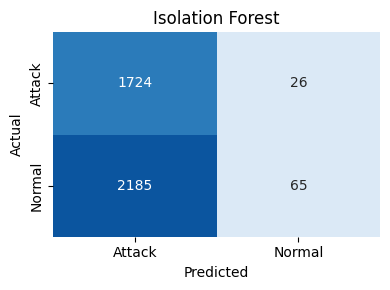

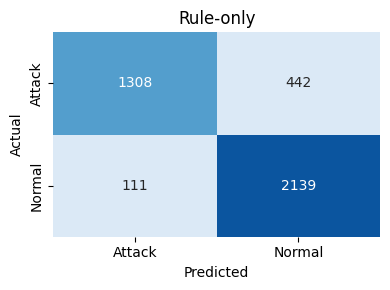

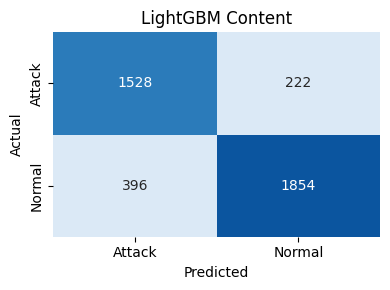

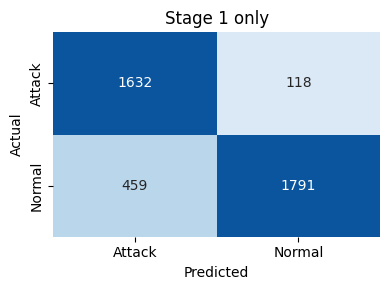

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
# In ra confusion matrix cho tung cau hinh
for name, tp, fp, fn, tn in configs:
    cm = np.array([[tp, fn], [fp, tn]])
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap=sns.color_palette("Blues"), cbar=False)
    plt.title(f"{name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks([0.5, 1.5], ["Attack", "Normal"])
    plt.yticks([0.5, 1.5], ["Attack", "Normal"])
    plt.tight_layout()
    plt.show()